# Weekly project part 1
Using the image "appletree.jpg"
1) Can you segment the apples from the tree?
2) Can you get the computer to count how many there are? 
    How close can you get to the ground truth? (there are 26 apples in the image)
3) Can you change the color of one of them?
4) Can you segment the leaves?
    
    
# Weekly project part 2
1) Remove the greenscreen and replace the background in "itssp.png".
2) Can you improve the edge with eroding/dilating?


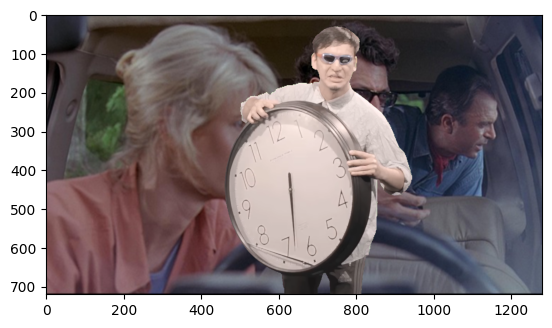

In [ ]:
#2)

import cv2
import numpy as np
import imutils
from matplotlib import pyplot as plt

P = "C:\\Users\\skiel\\Desktop\\fall26\\Perception\\"

fg = cv2.cvtColor(cv2.imread(P + "ittsp.png"), cv2.COLOR_BGR2RGB)
bg = cv2.cvtColor(cv2.imread(P + "jp.png"),    cv2.COLOR_BGR2RGB)
bg = cv2.resize(bg, (fg.shape[1], fg.shape[0]))     # backgrounds must match size


#Tried dialating and eroding fg and bg here

hsv = cv2.cvtColor(fg, cv2.COLOR_RGB2HSV)

lower = np.array([35,  40,  40])
upper = np.array([85, 255, 255])

green = cv2.inRange(hsv, lower, upper)

output = fg.copy()
output[green > 0] = (255, 255, 255)


#output = cv2.erode(output, None, iterations = 5)   Also tried dialating



#2.2) Messed with this a lot, strugugling to see clear edge improvement - although there is definatley a change.
#subject=cv2.erode(subject, None, iterations = 1)
#green = cv2.erode(green, None, iterations = 5)
# Tried before and after bitwise_not(green)


subject = cv2.bitwise_not(green)
m3 = cv2.merge((subject, subject, subject))
result = (fg & m3) | (bg & ~m3)
plt.imshow(result)

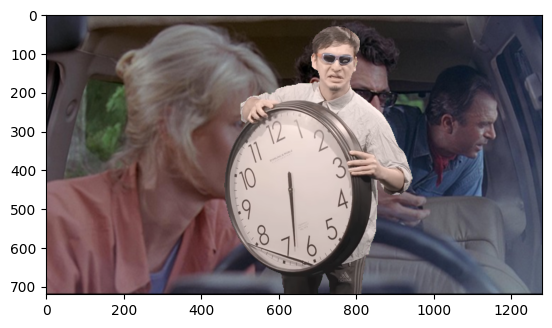

In [ ]:
#2.1)

import cv2
import numpy as np
import imutils
from matplotlib import pyplot as plt

P = "C:\\Users\\skiel\\Desktop\\fall26\\Perception\\"

fg = cv2.cvtColor(cv2.imread(P + "ittsp.png"), cv2.COLOR_BGR2RGB)
bg = cv2.cvtColor(cv2.imread(P + "jp.png"),    cv2.COLOR_BGR2RGB)
bg = cv2.resize(bg, (fg.shape[1], fg.shape[0]))     # backgrounds must match size


hsv = cv2.cvtColor(fg, cv2.COLOR_RGB2HSV)

lower = np.array([35,  40,  40])
upper = np.array([85, 255, 255])

green = cv2.inRange(hsv, lower, upper)

output = fg.copy()
output[green > 0] = (255, 255, 255)


subject = cv2.bitwise_not(green)


#2.2) Messed with this a lot, strugugling to see clear edge improvement - although there is definatley a change.
subject=cv2.erode(subject, None, iterations = 1)
#green = cv2.erode(green, None, iterations = 5)


#subject = cv2.bitwise_not(green)
m3 = cv2.merge((subject, subject, subject))
result = (fg & m3) | (bg & ~m3)
plt.imshow(result)

In [ ]:
#2.1)  (No chat)

import cv2
import numpy as np
import imutils
from matplotlib import pyplot as plt

P = "C:\\Users\\skiel\\Desktop\\fall26\\Perception\\"

fg = cv2.cvtColor(cv2.imread(P + "ittsp.png"), cv2.COLOR_BGR2RGB)
bg = cv2.cvtColor(cv2.imread(P + "jp.png"),    cv2.COLOR_BGR2RGB)
bg = cv2.resize(bg, (fg.shape[1], fg.shape[0]))     # backgrounds must match size


hsv = cv2.cvtColor(fg, cv2.COLOR_RGB2HSV)

lower = np.array([35,  40,  40])
upper = np.array([85, 255, 255])

green = cv2.inRange(hsv, lower, upper)

output = fg.copy()
output[green > 0] = (255, 255, 255)


subject = cv2.bitwise_not(green)
result = cv2.bitwise_and(bg, output, mask=green) 
plt.imshow(result)